# Methoden en Technieken 2025-2026 -- Blok 3 - Datapunt Opdracht 3B

## Opdracht

### Leer uitkomsten

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en technische requirements** op.
- B2: Je **stelt op basis van requirements** en data **een geschikte architectuur voor een AI-oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld** **machine learning**, **deep learning**, kennisrepresentatie, computer vision en natural language processing.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability, explainability, **model complexity** en resource demand.
(Leeruitkomst B1 is voor deze opdracht niet van toepassing.)

![](https://gymnasium.farama.org/_images/acrobot.gif)

## Uitleg

Het doel van deze opdracht is om een reinforcement learning model te maken dat het spel AcroBot speelt. Hier wil je een dubbele pendulum zo duwen dat het zo snel mogelijk een bepaalde hoogte bereikt.

Voor meer informatie over acties, belongingen, etc, zie [https://gymnasium.farama.org/environments/classic_control/acrobot/](https://gymnasium.farama.org/environments/classic_control/acrobot/).

- Stel een korte lijst van *requirements* op en verantwoord deze
- Kies een model en verantwoord je keuze
- Indien nodig, voer enkele (max 2) iteraties een verbeteringen uit, verantwoord je keuzes
- Evalueer je model (indien je .gif bestanden aanmaakt van gespeelde spellen, zoals in de code in de lessen, lever deze .gif bestanden ook in samen met dit notebook)
- Houd je antwoorden kort en bondig



De volgende code laad deze *environment* in.

## IMports

In [6]:
import gymnasium
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import copy
import time
from sb3_contrib import QRDQN
from torchinfo import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

env = gymnasium.make("Acrobot-v1", render_mode="rgb_array_list")

import imageio
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement, BaseCallback

Using device: cuda


## Omgeving

Het doel van deze opdracht is om een modelvrije reinforcement learning-oplossing te ontwikkelen voor de Acrobot-omgeving. In deze omgeving bestuurt een agent een tweedelige slinger, waarbij alleen het gewricht tussen de twee schakels actief wordt aangestuurd. Het doel is om door middel van het toepassen van koppel (torque) het vrije uiteinde van de slinger boven een bepaalde hoogte te krijgen, in zo min mogelijk stappen.

De taak is episodic en vereist dat de agent leert om momentum op te bouwen via gecoördineerde acties. Dit is niet triviaal, omdat directe beweging naar het doel niet mogelijk is; de agent moet eerst energie opbouwen via oscillerende bewegingen. De omgeving is gebaseerd op werk van Sutton’s generalization in reinforcement learning en Sutton en Barto’s boek, waarbij de dynamica continu en niet-lineair zijn, maar de interactie verloopt via een discrete actie-set.

### Belangrijke eigenschappen van de omgeving

- Continue toestandsruimte (hoeken gerepresenteerd als sinus en cosinus, plus hoeksnelheden)
- Discrete actieruimte met drie mogelijke koppelwaarden: −1, 0 en +1
- Onderliggend systeem is continu en niet-lineair, ondanks de discrete acties
- Beloningsstructuur: −1 per stap tot het doel wordt bereikt, 0 bij terminatie (minimaliseren van tijd)
- Episodes duren maximaal 500 stappen, dus een lange horizon
- Volledig observeerbare toestand, er is geen geheugen nodig
- Dynamica is onbekend en moet via interactie geleerd worden (modelvrij)
- Beginstatus is dicht bij rust, waardoor het opbouwen van momentum essentieel is

### Actieruimte

| Num | Actie                                  | Eenheid        |
|-----|----------------------------------------|----------------|
| 0   | Apply -1 torque op het gewricht        | torque (N·m)   |
| 1   | Apply 0 torque (geen kracht)           | torque (N·m)   |
| 2   | Apply +1 torque op het gewricht        | torque (N·m)   |

### Observatieruimte

| Num | Observatie                     | Min        | Max        |
|-----|-------------------------------|------------|------------|
| 0   | cos(θ₁)                       | -1         | 1          |
| 1   | sin(θ₁)                       | -1         | 1          |
| 2   | cos(θ₂)                       | -1         | 1          |
| 3   | sin(θ₂)                       | -1         | 1          |
| 4   | Hoeksnelheid θ₁               | -4π        | 4π         |
| 5   | Hoeksnelheid θ₂               | -9π        | 9π         |

Hierbij is θ₁ de hoek van de eerste schakel (0 = recht naar beneden), en θ₂ de relatieve hoek tussen de twee schakels.

### Beloning en terminatie

- Elke stap: reward = -1  
- Doel bereikt: reward = 0 en episode eindigt  
- Maximale episode lengte: 500 stappen  
- Terminatietrigger:  
  -cos(θ₁) - cos(θ₁ + θ₂) > 1.0  

### Starttoestand

Alle onderliggende toestandsvariabelen (hoeken en hoeksnelheden) worden willekeurig geïnitialiseerd in het interval [-0.1, 0.1]. Dit betekent dat de slinger vrijwel naar beneden hangt, met kleine variaties, waardoor actief momentum opbouwen noodzakelijk is.

## Functionele en technische requirements

1. Het systeem moet in staat zijn om stabiel te leren met functiebenadering (bijv. neurale netwerken), aangezien reinforcement learning methoden gevoelig zijn voor instabiliteit bij lange episodes.  
2. Het systeem moet effectief kunnen exploreren, omdat de beloningsstructuur vertraagd is en succes pas aan het einde van een episode wordt waargenomen.  
3. Het model moet geschikt zijn voor continue, niet-lineaire dynamica, aangezien het onderliggende systeem fysica-gebaseerd en continu is.  
4. De methode moet model-free zijn, omdat de overgangsdynamica van de omgeving niet expliciet beschikbaar is.  
5. Het systeem moet efficiënt omgaan met verzamelde ervaring, zodat training binnen redelijke tijd mogelijk blijft.  
6. Het model moet robuust zijn voor hyperparameterkeuzes, aangezien gevoeligheid kan leiden tot instabiele of inconsistente prestaties.  
7. Het systeem moet schaalbaar zijn naar langere episodes (tot 500 stappen) zonder dat prestaties sterk verslechteren.  
8. Het model moet werken met een discrete maar controle-georiënteerde actieruimte, waarbij acties een benadering vormen van continue controle.  
9. Het systeem mag geen afhankelijkheid hebben van geheugen of sequentiële modellering, aangezien de volledige toestand observeerbaar is.  
10. De modelcomplexiteit moet beperkt blijven en afgestemd zijn op de lage dimensie van de toestandsruimte, om overfitting en onnodige rekentijd te voorkomen.  
11. Er moet een relevante baseline worden gedefinieerd (bijv. een random agent of eenvoudige heuristische policy) die dient als ondergrens voor prestaties.  
12. De gekozen methode moet aantoonbaar beter presteren dan de baseline, gemeten in termen van gemiddelde episodische return en/of het aantal stappen tot het behalen van het doel.  
13. Het model moet een grote hebben die passend is voor de complexiteit van het probleem

### Toelichting op trade-offs

Deze requirements volgen direct uit de eigenschappen van de Acrobot-omgeving: continue dynamica, vertraagde beloningen en lange episodes maken stabiliteit en exploratie de belangrijkste uitdagingen. Tegelijkertijd ontstaat er een spanningsveld tussen stabiliteit en efficiëntie, aangezien on-policy methoden doorgaans stabieler zijn en off-policy methoden efficiënter omgaan met data. In deze opdracht wordt gekozen voor methoden die een balans bieden tussen beide. Daarnaast bestaat er een trade-off tussen modelcomplexiteit en efficiëntie, waarbij bewust wordt gekozen voor een compact model passend bij de lage-dimensionale toestandsruimte. Moderne methoden zoals Soft Actor-Critic (off-policy maximum entropy reinforcement learning) laten zien dat het mogelijk is om deze trade-offs effectief te balanceren.

## Modelkeuze

### Gemaakte keuzes

**Uitdagingen op basis van environment**

De Acrobot-omgeving is een model free controleprobleem met continue, niet-lineaire dynamiek en een kleine discrete actieruimte. Hoewel de acties discreet zijn, uit dit zich in een continue controle. In combinatie met lange episodes (tot 500 stappen) en een reward van −1 per stap ontstaat een dichte maar zwak informatieve rewardstructuur. De belangerijskte uitdagingen voor het gekozen model om op te lossen.

- Stabiliteit
- Exploration
- Robustness voor leren over een lange horizon

**Eerste selectie: modelvrije reinforcement learning**

Om een keuze te maken aan de hand van de vele mogelijkheden heb ik de spinning up flow chart van OpenAI gebruikt die om een snelle overview te krijgen van de opties. De eerste keuze die gemaakt is is tussen de model-based en model free methoden. Model free is gekozen omdat de dynamics van de omgeving niet expliciet beschikbaar zijn en doormiddel van interactie met de environment geleerd moeten worden. 


<img src="./model_selection_flow_chart.png" alt="model choice flow" width="500"/>

**Tweedeling: policy optimization vs Q-learning**

Binnen modelvrije methoden ontstaat een keuze tussen:

- Policy optimization / actor–critic (DDPG, TD3, SAC)  
- Q-learning (DQN en varianten)  

Actor–critic methoden hebben als voordeel dat ze sterk zijn in continue controle en hhet bieden van stabielere updates *[1](H3, pg 4: "The weights of these target networks are then updated by having them slowly track the learned networks... This means that the target values are constrained to change slowly, greatly improving the stability of learning.")*. Het nadeel is dat ze actor-critic methoden gelijktijdig een policy leren en een value function dit kan er toe leiden datde oplossing complexer is en meer hyperparameters heeft. Omdat de acrobot omgeving een kleine discrete ruimte heeft gaat en gaat de voorkeur uit voor value-based methods. De eerste bekeken modellen zijn daarom de Q-learning based methods met als alternatief de actor-critics die mogelijk voordeel bieden als er veelr uis is door de randomness in de environment.

**Verfijning via RL-Picker en literatuur**

Om de verdere keuze te maken op basis van de selectie van de flow chart is er gebruik gemaakt van de RL-Picker tool op basis van de paper van [2] de paper is niet zo vaak geciteerd en daarom is het gebruikt als een cross validation met de selectie van de flow chart en om verdere selectie te ondersteunen en een sterk overzicht te hebben van modellen en de bijhorende papers. De volgende settings zijn gebruikt op basis van het probleem beschreven boven aan de notebook en de requirements. 

De setting die beiden kanten op kan gaan is de "rewards" sectie met de opties non-deceptive and quite dense, of sparse, deceptive or unclear in advance. Ondanks dat succes pas aan het einde zichtbaar is is er een dense maar weak signaal omdat er constant feedback is op de status van het doel. De resultaten van de tool laten het volgende zien:

<img src="./rl_picker_selection.png" alt="model choice flow" width="1400"/>

**De RL-Picker was gebruikt voor een snel overzicht van mogelijkheden, en om extra validatie te doen op mijn eigen onderzoek**

<br>

Bij de flow chart waren de actor-critics voor nu achterwegen gelaten en in de picker hier is dit ook terug te zien, distributional methoden krijgen ook hier de voorkeur voor deze context vanwegen stabiliteit en verwachte betere representaties omdat ze variatie verminderen in value estimates voor een stabielere leer dynamiek *[3](H1: "The distributional Bellman operator preserves multimodality in value distributions, which we believe leads to more stable learning. Approximating the full distribution also mitigates the effects of learning from a nonstationary policy. As a whole we argue that this approach makes approximate reinforcement learning significantly better behaved)* , de actor-critics zijn zoals te zien als nog een valid alternatief. Van de 4 modellen uit de flow chart zijn er na het vergelijken nog 2 opties C51 en QR-DQN de andere twee modellen vallen af omdat ze Not distributional zijn en DQN bekend staat om instabiliteit en overestimation bias bij functiebenadering bekend staat *[4](Results on overoptimism, pg 5 :"Notice that the increases in value estimates for DQN [...] coincide with decreasing scores. [...] This indicates that the overestimations are harming the quality of the resulting policies... suggesting that the cause for these instabilities is in fact Q-learning's overoptimism.")*. De RL-Picker tool [2] beschrijft ook, met verwijzing naar [5][6]: "Distributional approaches are preferred instead because they may improve exploration generalization, training stability, and overall performance at the cost of training an additional density estimator"

De tooll geeft ook nog 2 andere opties die niet in de flow chart zijn GAN Q-learning en Bootstrapped DQN, deze zijn uitgesloten omdat GAN Q-learning meer risico heeft op instabiliteit en minder praktisch toepasbaar is. Bootstrapped DQN heeft als voordeel dat het beter instaat is goede resultaten te halen, maar hier staat tegen over dat het voor complexere exploration problemen is en meer rekentijd nodig heeft..

Met behulp van de flow chart en een extra check met de RL-picker tool en informatie van de paper blijven twee logische opties over:
De laatste keuze is nu tussen, de twee distributional reinforcement learning methodes lijken logische keuzes omdat ze  niet alleen de verwachte return leren, maar de volledige verdeling. Distributional methoden helpen hierbij om ruis in de value estimation te verminderen door de volledige verdeling te modelleren, zonder de extra complexiteit van een actor-critic architectuur. Dit heeft de volgende effecten:

- stabielere updates  
- betere representaties van onzekerheid  

- Distributional DQN (also called c51)
- QR-DQN

**Vergelijking: C51 vs QR-DQN  

Beide methoden behoren tot distributional reinforcement learning en modelleren de volledige returnverdeling, wat helpt bij het verminderen van variantie en instabiliteit.

Het verschil zit in de representatie:

- **C51** gebruikt een vaste, discreet support  
  - vereist vooraf gekozen grenzen voor de return  
  - gevoelig voor verkeerde assumptions  

- **QR-DQN** leert direct de quantiles van de verdeling  
  - geen vooraf gedefinieerde support nodig  
  - flexibeler en beter aanpasbaar aan de omgeving  

In een omgeving zoals Acrobot, waar de returnverdeling niet eenvoudig vooraf te bepalen is, is dit een belangrijk voordeel. De paper van Dabney et al. *[10](Abstract: " Finally, we evaluate this new algorithm on the Atari 2600 games, observing that it significantly outperforms many of the recent improvements on DQN, including the related distributional algorithm C51.")* laat zien dat QR-DQN vaak beter presteert dan C51.

### Definitieve keuze  

Op basis van bovenstaande analyse wordt gekozen voor:

**Quantile Regression DQN (QR-DQN)**  

QR-DQN modelleert de volledige verdeling van returns met behulp van vaste quantilefracties, in plaats van enkel de gemiddelde Q-waarde te schatten. Hierdoor krijgt de agent een bredere en gedetailleerder beeld van de onzekerheid in value estimation, wat kan helpen voor een stabieler leerproces en betere exploration. De lossfunctie maakt gebruik van de quantile Huber loss om elke quantile richting de targetverdeling te regressen.

**Kernidee**: In plaats van alleen $Q(s, a)$ te voorspellen, voorspelt het netwerk $N$ quantiles $\theta_i(s, a)$ voor $i = 1, \ldots, N$, met vaste quantile midpoints $\tau_i = \frac{2i - 1}{2N}$.

Deze methode biedt een sterke combinatie van:

- stabiliteit (door distributional learning)  
- flexibiliteit (geen vaste returngrenzen)  
- een rijkere representatie van onzekerheid (via quantiles)  
- goede aansluiting bij discrete acties  

Hiermee vormt QR-DQN een logische keuze binnen de geïdentificeerde oplossingsruimte, die op basis van stapsgewijze modelkeuzes en het systematisch vergelijken en uitsluiten van alternatieven consistent naar voren komt.

### Iteratiestrategie  

Hoewel QR-DQN als primaire methode wordt gekozen, blijven er mogelijke vervolgstappen voor een tweede iteratie.

Indien tijdens training blijkt dat er als nog veel instabiliteit is of hoge variantie ondanks dat dedistrbutions hier bij zouden moeten helpen, is het misschien nodig om als tweede iteratie een ander model te keizen zoals een actor–critic methode zoals SAC, die stabiliteit nog verder kan verbeteren via een andere aanpak (entropy-regularisatie).  

Als het blijkt dat de prestaties goed en stabiel zijn  is een betere keuze voor een tweede iteratie hter verder optimaliseren van QR-DQN, met hyper param tuning of een architecture change aan de hand van de resultaten.

### Conclusie  

De modelkeuze volgt een systematische reductie van het oplossingsdomein: van modelvrije methoden naar Q-learning, vervolgens naar distributional varianten, en uiteindelijk naar QR-DQN als meest geschikte methode. Deze keuze sluit het beste aan bij de eigenschappen van de omgeving en de gestelde requirements, terwijl er ruimte blijft voor gerichte iteratie.

## Hyperparameterkeuze en onderbouwing

### Overzicht van hyperparameters

**Modelarchitectuur**

* `net_arch`: bepaalt de capaciteit van het neurale netwerk. Grotere netwerken kunnen complexere waarde-functies modelleren maar zijn trager en gevoeliger voor instabiliteit.
* `n_quantiles`: bepaalt hoe fijnmazig de returnverdeling wordt benaderd. Meer quantielen geven een nauwkeurigere distributie maar verhogen de complexiteit en rekentijd.

**Leerproces**

* `learning_rate`: bepaalt hoe snel het model leert. Te hoog geeft instabiliteit, te laag vertraagt convergentie.
* `batch_size`: aantal samples per update. Grotere batches geven stabielere gradients maar vereisen meer data.
* `gamma`: discount factor die bepaalt hoeveel toekomstige beloningen meewegen. Interageert sterk met episode-lengte.
* `learning_starts`: aantal stappen dat het model data verzamelt voordat het begint met leren. Dit zorgt ervoor dat de replay buffer voldoende gevuld is met diverse ervaringen voordat updates plaatsvinden, wat bijdraagt aan stabiliteit in de vroege trainingsfase.

**Exploratie**

* `exploration_initial_eps`: startniveau van willekeurig gedrag.
* `exploration_final_eps`: minimale exploratie na afname.
* `exploration_fraction`: welk deel van de training wordt besteed aan afbouw van exploratie. Deze parameters bepalen samen de balans tussen ontdekken en benutten.

**Stabiliteit en updates**

* `target_update_interval`: frequentie van updates van het target network. Te frequent kan instabiliteit veroorzaken, te infrequent vertraagt leren.
* `train_freq` en `gradient_steps`: bepalen hoe vaak en hoe intensief het model leert uit de replay buffer.

**Sample-efficiëntie**

* `buffer_size`: grootte van de replay buffer. Een grotere buffer verhoogt diversiteit maar kan oudere, minder relevante ervaringen bevatten.

**Trainingsbudget**

* `total_timesteps`: totaal aantal interacties met de omgeving. Bepaalt hoeveel tijd het model heeft om te convergeren.

Deze parameters werken samen: bijvoorbeeld vereist een kleiner netwerk vaak minder agressieve updates en een lagere complexiteit in de distributiebenadering, terwijl exploratie-instellingen bepalen of het model überhaupt bruikbare ervaringen verzamelt.

### Hyperparameters iteratie 1

De gekozen configuratie is gebaseerd op bestaande, geoptimaliseerde instellingen uit de RL Baselines3 Zoo [7] en resultaten uit de studie van Robust Reinforcement Learning with Distributional Risk-averse formulation [7]. Beide bronnen tonen aan dat Acrobot effectief kan worden opgelost met relatief grote netwerken (256×256) en een hoog aantal quantielen (±25).

In deze iteratie wordt echter bewust gekozen voor een **kleinere en efficiëntere architectuur**, in lijn met de projectvereisten. Alleen hyperparameters die direct afhankelijk zijn van modelgrootte worden aangepast, terwijl de overige instellingen uit de literatuur worden overgenomen om stabiliteit te behouden.

#### Gekozen configuratie

**Modelarchitectuur**

* `net_arch = [16, 16]`
* `n_quantiles = 8`

De literatuur gebruikt aanzienlijk grotere netwerken (256×256) met 25 quantielen [7][8], en de standaardwaarde van QR-DQN in Stable Baselines3 is 200 quantielen. De keuze voor 8 quantielen is dus een reductie van 96%, wat een bewuste en agressieve verkleining is. Aangezien de toestandsruimte van Acrobot laag-dimensionaal is (6 features), kan een klein netwerk in principe voldoende representatiekracht hebben.

Het sterk verlaagde aantal quantielen betekent echter dat de returnverdeling slechts grof wordt benaderd, waardoor een deel van het voordeel van distributional RL verloren gaat. Dit is een bewuste trade-off: de eerste iteratie test of de kernvoordelen van QR-DQN (stabielere updates, betere representatie van onzekerheid) ook met een minimale configuratie behouden blijven. Indien de resultaten onvoldoende zijn, kan in een tweede iteratie het aantal quantielen worden verhoogd om de nauwkeurigheid van de distributiebenadering te verbeteren.

**Leerproces**

* `learning_rate = 6.3e-4`
* `batch_size = 128`
* `gamma = 0.99`
* `learning_starts = 100` (standaardwaarde)

De learning rate, batch size en gamma zijn direct overgenomen uit beide bronnen [7][8]. Ze zijn empirisch geoptimaliseerd en onafhankelijk van modelgrootte.

De hoge discount factor is noodzakelijk vanwege de lange horizon van de taak, terwijl de batch size zorgt voor stabiele updates zonder overmatige rekentijd.

Voor `learning_starts` wordt de standaardwaarde van 100 stappen behouden. Bij een buffer van 50.000 is dit voldoende om een initiële set ervaringen te verzamelen voordat het leerproces begint, zonder onnodige vertraging aan het begin van de training.

**Exploratie**

* `exploration_initial_eps = 1.0`
* `exploration_final_eps = 0.05`
* `exploration_fraction = 0.15`

De exploratieparameters zijn grotendeels gebaseerd op de tuned instellingen uit [7], met een lichte aanpassing van de eindwaarde.

Een relatief korte exploratiefase voorkomt dat het model te lang willekeurig gedrag vertoont, terwijl een niet te lage eindwaarde ervoor zorgt dat het model blijft variëren en niet te vroeg convergeert naar een suboptimale strategie.

**Stabiliteit en updates**

* `target_update_interval = 250`
* `train_freq = 4`
* `gradient_steps = 1`

Deze waarden zijn overgenomen uit de literatuur [7][8] en bepalen de frequentie en intensiteit van het leerproces.

Frequentere target updates zorgen voor snellere propagatie van nieuwe kennis, terwijl de combinatie van `train_freq` en `gradient_steps` een gebalanceerde verhouding geeft tussen data verzamelen en leren.

**Sample-efficiëntie**

* `buffer_size = 50000`

Overgenomen uit beide bronnen. Groot genoeg om diverse ervaringen op te slaan zonder inefficiënt te worden.

**Trainingsbudget**

* `total_timesteps = 200000`

Verdubbeld ten opzichte van de Zoo-instelling (100k) om de kleinere architectuur voldoende leertijd te geven. Kleinere modellen hebben doorgaans meer interacties nodig om vergelijkbare prestaties te bereiken.


## Evaluation Strategy

Om de prestaties van het getrainde QR-DQN model te beoordelen worden er 4 dingen ge-evalueerd:

1. Leercurve-analyse: Tijdens de training worden de per-episode returns gelogd en gevisualiseerd. Zowel de raw per-episode returns als een smooth variant (moving average, window=50) worden getoond. De ruwe data maakt de episodische noise zichtbaar, wat inzicht geeft in de variantie van het leerproces en de mate waarin de distributional benadering (quantiles) deze noise al dan niet volledig dempt. De smoothed curve toont de onderliggende leertrend: convergentiesnelheid, stabiliteit en eventuele tekenen van overtraining.

2. Vergelijking met baselines: Het model wordt vergeleken met twee referentiepunten (zie sectie hieronder). Een random agent als ondergrens voor een sanity check, en de state-of-the-art benchmark uit de SB3-contrib documentatie als bovengrens. Dit plaatst de behaalde prestaties in context.

3. Visuele sanity check: Er wordt een GIF gegenereerd van het model dat de Acrobot-omgeving speelt. Dit biedt een kwalitatieve controle op het aangeleerde gedrag: swingt het model daadwerkelijk omhoog, of vertoont het willekeurig gedrag?

4. Evaluatie op verse episodes: Het getrainde model wordt geëvalueerd op 100 volledig nieuwe episodes (zonder exploratie). Hiermee wordt de generalisatie gemeten los van de trainingsdynamiek. De gemiddelde return en standaarddeviatie worden berekend en vergeleken met de baseline. Daarnaast wordt de distributie van returns gevisualiseerd via histogrammen en een box+strip plot van het model om consistentie en eventuele uitschieters te identificeren.

## Baseline

Er worden twee baselines gebruikt om de prestaties van het model in perspectief te plaatsen:

1. Random Agent (ondergrens)
De primaire baseline is een agent die volledig willekeurig acties selecteert. Deze dient als sanity check: als het getrainde model niet significant beter presteert dan random, dan heeft het model effectief niets geleerd. Voor Acrobot-v1 behaalt een random agent doorgaans een return rond −500 (de maximale episode-lengte), omdat willekeurige acties vrijwel nooit leiden tot het bereiken van het doel. Dit maakt het een heldere ondergrens waartegen elke verbetering meetbaar is.

2. SB3-contrib Benchmark (bovengrens)
Als secundaire referentie worden de gepubliceerde resultaten van Stable-Baselines3-contrib gebruikt. Op de Acrobot-omgeving rapporteren zij de volgende scores, getraind met standaard hyperparameters en grote netwerken [9]

| Algoritme | Mean Return |
|-----------|-------------|
| QR-DQN    | −73 ± 2     |
| DQN       | −74 ± 2     |

Deze resultaten zijn behaald met aanzienlijk grotere architecturen (standaard 64×64, 200 quantielen) en dienen als referentie voor wat optimaal haalbaar is. Het doel is niet om deze scores exact te evenaren, maar om te begrijpen waar het eigen model zich bevindt ten opzichte van de bovenlimiet. Het verschil in prestatie kan direct worden verklaard door de bewuste keuze voor een compactere architectuur, wat in lijn is met de gestelde requirements rondom modelcomplexiteit.

## Training

In [7]:
from stable_baselines3.common.callbacks import BaseCallback

class RewardLoggerCallback(BaseCallback):
    """Logs episode rewards during training."""
    def __init__(self):
        super().__init__()
        self.episode_rewards = []

    def _on_step(self):
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
        return True

policy_kwargs = dict(
    net_arch=[16, 16],
    n_quantiles=8
)

total_timesteps=200_000
log_interval=100

model = QRDQN(
    "MlpPolicy",
    "Acrobot-v1",
    policy_kwargs=policy_kwargs,
    learning_rate=6.3e-4,
    batch_size=128,
    gamma=0.99,
    buffer_size=50000,
    target_update_interval=250,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.15,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
)

Using cuda device
Creating environment from the given name 'Acrobot-v1'
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [8]:
# total_params = sum(p.numel() for p in model.policy.parameters())
# print(f"Total parameters: {total_params}")
# print(model.policy)

Total parameters: 1584
QRDQNPolicy(
  (quantile_net): QuantileNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (quantile_net): Sequential(
      (0): Linear(in_features=6, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=24, bias=True)
    )
  )
  (quantile_net_target): QuantileNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (quantile_net): Sequential(
      (0): Linear(in_features=6, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=24, bias=True)
    )
  )
)


In [9]:
# print(model.policy)

# # Feature extractor (usually identity or flatten for MLP)
# print("Features extractor:")
# print(model.policy.features_extractor)

# # Q-network (main network)
# print("\nQ-network:")
# print(model.policy)

# # Target network
# print("\nTarget Q-network:")
# print(model.policy.quantile_net)

# for name, param in model.policy.named_parameters():
#     print(f"{name}: {param.shape} -> {param.numel()} params")

# summary(model.policy, input_size=(1, 6))  # Acrobot has 6 state features


In [10]:
print("Training QR-DQN (sb3-contrib)...")
reward_callback = RewardLoggerCallback()
start_time = time.time()

model.learn(total_timesteps=total_timesteps, log_interval=log_interval, callback=reward_callback)
train_time = time.time() - start_time

model.save("qrdqn_acrobot")
qrdqn_rewards = reward_callback.episode_rewards
print(f"Training complete in {train_time:.1f}s, {len(qrdqn_rewards)} episodes")

Training QR-DQN (sb3-contrib)...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 435      |
|    ep_rew_mean      | -435     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 100      |
|    fps              | 616      |
|    time_elapsed     | 70       |
|    total_timesteps  | 43530    |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 2.34     |
|    n_updates        | 10857    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 172      |
|    ep_rew_mean      | -171     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 200      |
|    fps              | 593      |
|    time_elapsed     | 102      |
|    total_timesteps  | 60734    |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             

## Evaluation

In [18]:
print("Evaluating on 100 fresh episodes \n")

# QR-DQN evaluation
eval_env = gymnasium.make("Acrobot-v1")
qrdqn_returns = []
for _ in range(100):
    state, _ = eval_env.reset()
    total_reward = 0
    done = False
    while not done:
        action, _ = model.predict(state, deterministic=True)
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
    qrdqn_returns.append(total_reward)
eval_env.close()
qrdqn_mean, qrdqn_std = np.mean(qrdqn_returns), np.std(qrdqn_returns)

# Random baseline
eval_env = gymnasium.make("Acrobot-v1")
rand_returns = []
for _ in range(100):
    state, _ = eval_env.reset()
    total_reward = 0
    done = False
    while not done:
        action = eval_env.action_space.sample()
        state, reward, terminated, truncated, _ = eval_env.step(action)
        total_reward += reward
        done = terminated or truncated
    rand_returns.append(total_reward)
eval_env.close()
rand_mean, rand_std = np.mean(rand_returns), np.std(rand_returns)

print(f"{'Model':<20} {'Mean Return':>12} {'Std':>8}")
print("-" * 44)
print(f"{'Random Baseline':<20} {rand_mean:>12.1f} {rand_std:>8.1f}")
print(f"{'QR-DQN':<20} {qrdqn_mean:>12.1f} {qrdqn_std:>8.1f}")
print(f"\nImprovement over baseline: {qrdqn_mean - rand_mean:+.1f} return")

Evaluating on 100 fresh episodes...

Model                 Mean Return      Std
--------------------------------------------
Random Baseline            -499.7      2.7
QR-DQN                      -95.3     43.7

Improvement over baseline: +404.4 return


C:\Users\Frank\AppData\Local\Temp\ipykernel_16600\3842742012.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5, showmeans=True,


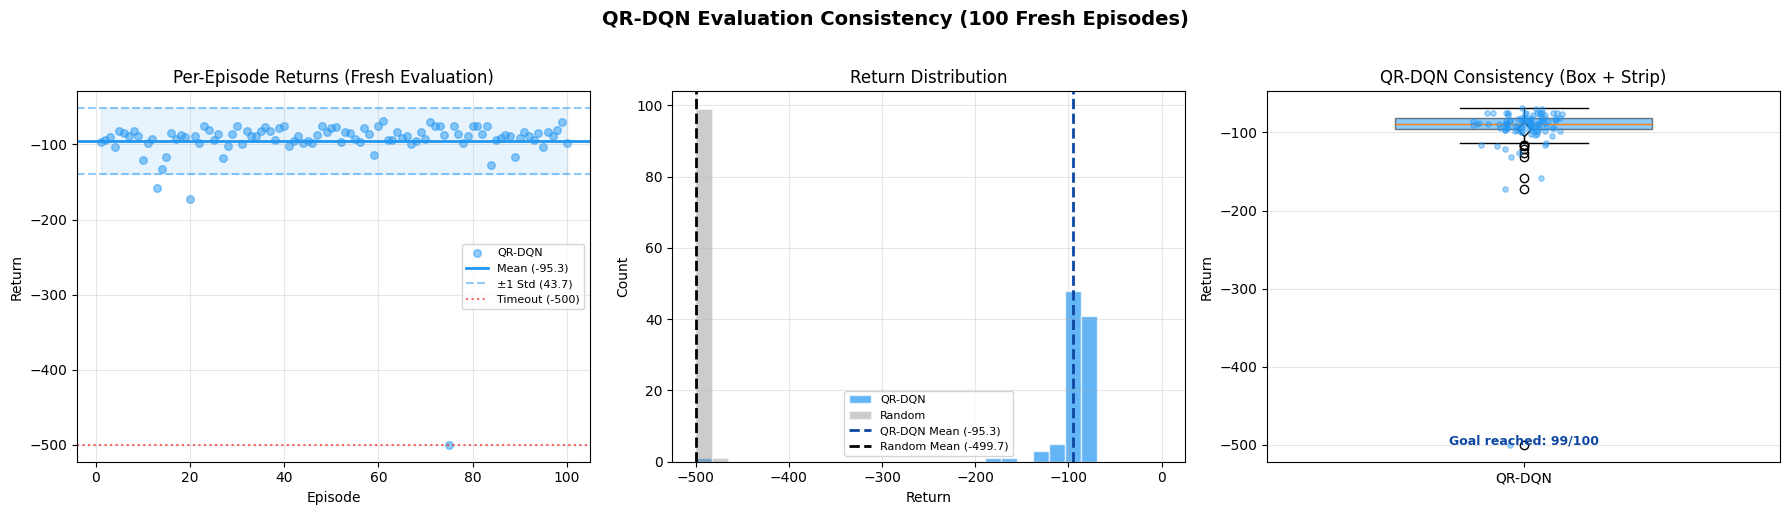

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Per-episode returns scatter — shows every episode so you can see consistency
ax = axes[0]
episodes = np.arange(1, len(qrdqn_returns) + 1)
ax.scatter(episodes, qrdqn_returns, alpha=0.5, s=30, color="#2196F3", label="QR-DQN")
ax.axhline(y=qrdqn_mean, color="#2196F3", linestyle="-", linewidth=2, label=f"Mean ({qrdqn_mean:.1f})")
ax.axhline(y=qrdqn_mean + qrdqn_std, color="#2196F3", linestyle="--", alpha=0.5, label=f"±1 Std ({qrdqn_std:.1f})")
ax.axhline(y=qrdqn_mean - qrdqn_std, color="#2196F3", linestyle="--", alpha=0.5)
ax.fill_between(episodes, qrdqn_mean - qrdqn_std, qrdqn_mean + qrdqn_std, color="#2196F3", alpha=0.1)
ax.axhline(y=-500, color="red", linestyle=":", alpha=0.6, label="Timeout (-500)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Per-Episode Returns (Fresh Evaluation)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2) Histogram — shows distribution shape and whether there are failure clusters
ax = axes[1]
bins = np.linspace(min(min(qrdqn_returns), min(rand_returns)), 0, 30)
ax.hist(qrdqn_returns, bins=bins, alpha=0.7, color="#2196F3", edgecolor="white", label="QR-DQN")
ax.hist(rand_returns, bins=bins, alpha=0.4, color="gray", edgecolor="white", label="Random")
ax.axvline(x=qrdqn_mean, color="#0D47A1", linestyle="--", linewidth=2, label=f"QR-DQN Mean ({qrdqn_mean:.1f})")
ax.axvline(x=rand_mean, color="black", linestyle="--", linewidth=2, label=f"Random Mean ({rand_mean:.1f})")
ax.set_xlabel("Return")
ax.set_ylabel("Count")
ax.set_title("Return Distribution")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Box + strip plot — shows only QR-DQN consistency
ax = axes[2]
data = [qrdqn_returns]
labels = ["QR-DQN"]
colors_box = ["#2196F3"]
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=7))
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
# Overlay individual points (jittered)
jitter = np.random.normal(0, 0.04, size=len(qrdqn_returns))
ax.scatter(np.full(len(qrdqn_returns), 1) + jitter, qrdqn_returns, alpha=0.4, s=15, color="#2196F3", zorder=3)
ax.set_ylabel("Return")
ax.set_title("QR-DQN Consistency (Box + Strip)")
ax.grid(True, alpha=0.3, axis="y")

# Success rate annotation
qrdqn_success = sum(1 for r in qrdqn_returns if r > -500)
ax.annotate(f"Goal reached: {qrdqn_success}/{len(qrdqn_returns)}", xy=(1, min(qrdqn_returns)),
            fontsize=9, ha="center", color="#0D47A1", fontweight="bold")

plt.suptitle("QR-DQN Evaluation Consistency (100 Fresh Episodes)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("qrdqn_consistency.png", dpi=150, bbox_inches='tight')
plt.show()

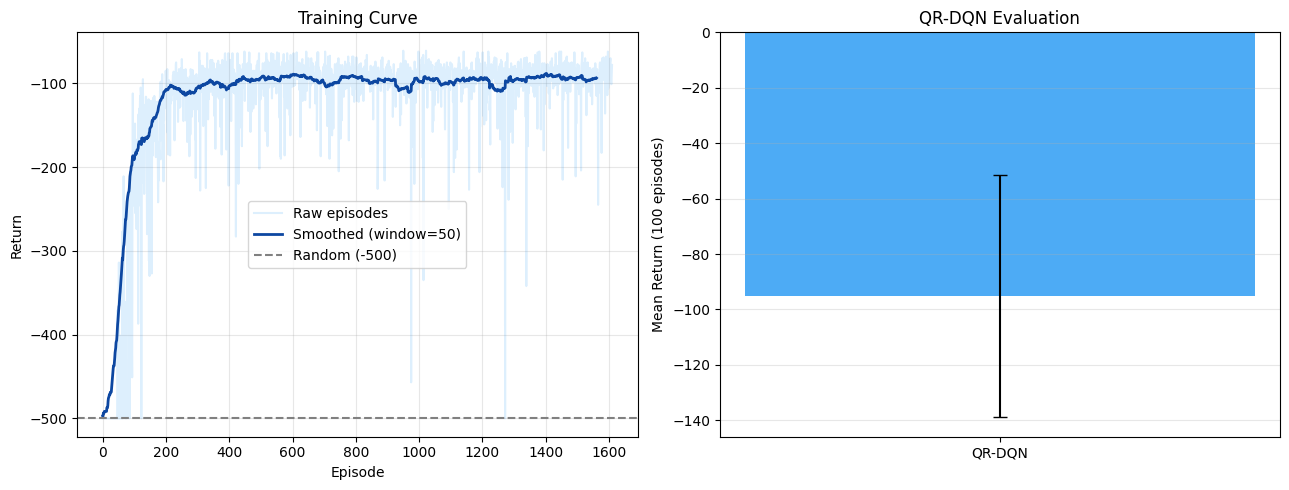

In [42]:
def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training curve
ax = axes[0]
ax.plot(qrdqn_rewards, alpha=0.15, color="#2196F3", label="Raw episodes")
ax.plot(smooth(qrdqn_rewards), label="Smoothed (window=50)", color="#0D47A1", linewidth=2)
ax.axhline(y=rand_mean, color='gray', linestyle='--', label=f"Random ({rand_mean:.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Training Curve")
ax.legend()
ax.grid(True, alpha=0.3)

# Final evaluation
ax = axes[1]
ax.bar(["QR-DQN"], [qrdqn_mean], yerr=[qrdqn_std], capsize=5, color=["#2196F3"], alpha=0.8)
ax.set_ylabel("Mean Return (100 episodes)")
ax.set_title("QR-DQN Evaluation")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("qrdqn_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

## Analysis of results

De huidige QR-DQN configuratie met een compacte architectuur (16×16, 8 quantielen, 1584 parameters) leert de Acrobot-taak snel en stabiel. Tijdens training convergeert het model consistent naar een gemiddelde return rond −95 tot −100. Evaluatie op 100 nieuwe episodes bevestigt dit met −95.3 ± 43.7, wat een duidelijke verbetering is ten opzichte van de random baseline (~ −500). De baseline werkt als sanity check en laat zien dat het model daadwerkelijk iets leert.

Wanneer de resultaten vergeleken worden met de bestaande benchmark uit de literatuur is te zien dat hogere prestatie mogelijk is zoals bij de SB3 evaluatie. Daar zijn resultaten van (± −73) gehaald. Dit model is wel enorm veel groter door het gebruik van veel meer neuronen en meer quantiles.

De ruwe trainingscurve laat zien dat er ondanks convergentie nog significante episodische ruis aanwezig blijft, met name in de latere trainingsfase na convergentie. Dit suggereert dat de 8 quantielen niet voldoende zijn om de variantie in de value estimation volledig te dempen. Rond het convergentiepunt zelf is de ruis beperkt en acceptabel, maar bij langer doortrainen neemt de instabiliteit toe, wat wijst op lichte overtraining. Eerder stoppen, kort na convergentie, zou dit probleem voorkomen.

Ondanks deze observatie voldoet het model aan de belangrijkste requirements. Het leert stabiel tot aan convergentie, maakt efficiënt gebruik van data en presteert consistent beter dan de baseline.

**Behaald**

(1) Het systeem moet in staat zijn om stabiel te leren met functiebenadering — *behaald tot aan convergentie, daarna lichte instabiliteit*
(2) Het systeem moet effectief kunnen exploreren
(3) Het model moet geschikt zijn voor continue, niet-lineaire dynamica
(4) De methode moet model-free zijn
(5) Het systeem moet efficiënt omgaan met verzamelde ervaring
(7) Het systeem moet schaalbaar zijn naar langere episodes
(8) Het model moet werken met een discrete actieruimte
(9) Het systeem mag geen afhankelijkheid hebben van geheugen
(10) De modelcomplexiteit moet beperkt blijven en afgestemd zijn op de lage dimensie
(11) Er moet een relevante baseline worden gebruikt
(12) Het model moet beter presteren dan de baseline

**Niet of deels behaald**

(1) Stabiel leren — *deels: stabiel rond convergentie, maar ruis neemt toe bij langer doortrainen, wat suggereert dat het lage aantal quantielen onvoldoende is om variantie volledig te absorberen*
(6) Het model moet robuust zijn voor hyperparameterkeuzes
(13) Het model moet een grootte hebben die passend is voor de complexiteit van het probleem

In [32]:
env = gymnasium.make("Acrobot-v1", render_mode="rgb_array")
frames = []

state, _ = env.reset()
done = False
while not done:
    frame = env.render()
    frames.append(frame)
    action, _ = model.predict(state, deterministic=True)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

# Capture final frame
frames.append(env.render())
env.close()

imageio.mimsave("qrdqn_acrobot.gif", frames, fps=30, loop=0)
print(f"Saved GIF with {len(frames)} frames")

Saved GIF with 80 frames


<img src="./qrdqn_acrobot.gif" alt="model choice flow" width="300"/>

## Iteratie 2

Op basis van de resultaten en de eerder opgestelde requirements zijn er twee logische vervolgstappen. De performance kan verder worden verbeterd door het model te vergroten of extra hyperparameteroptimalisatie toe te passen, zoals in de literatuur. Alternatief kan de modelcomplexiteit verder worden verlaagd terwijl de prestaties behouden blijven.

Gezien de requirements ligt de nadruk op efficiëntie en passendheid bij de lage-dimensionale omgeving. Met name requirement *(10) modelcomplexiteit* is nog verder te optimaliseren, aangezien het huidige model met 1584 parameters mogelijk nog redelijk groot is voor de complexiteit van het probleem. De requirement *(6) robuustheid voor hyperparameters* is niet gehaald omdat de architectuur gevoelig is voor hyper parameter aanpassingen en dit wordt voor nu achter wegen gelaten om eerst te focussen op de verkleining van het model.

Daarom wordt in iteratie 2 gekozen om de modelarchitectuur verder te verkleinen. Om te blijven voldoen aan requirement *(1) stabiel leren* en *(5) sample-efficiëntie*, wordt de batch size verhoogd. Een grotere batch helpt de variantie in de updates te verminderen en compenseert daarmee voor de hogere gevoeligheid van een kleiner netwerk.

Alle overige hyperparameters blijven ongewijzigd om een gecontroleerde vergelijking te behouden. Het doel van deze iteratie is om te onderzoeken hoe ver de modelcomplexiteit gereduceerd kan worden zonder dat de prestaties significant verslechteren en terwijl nog steeds wordt voldaan aan de belangrijkste requirements.


In [24]:
policy_kwargs_it2 = dict(
    net_arch=[8, 8],
    n_quantiles=8
)

total_timesteps_it2 = 200_000
log_interval_it2 = 100

model_it2 = QRDQN(
    "MlpPolicy",
    "Acrobot-v1",
    policy_kwargs=policy_kwargs_it2,
    learning_rate=6.3e-4,
    batch_size=256,
    gamma=0.99,
    buffer_size=50000,
    target_update_interval=250,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.15,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
)

Using cuda device
Creating environment from the given name 'Acrobot-v1'
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [27]:
total_params_it2 = sum(p.numel() for p in model_it2.policy.parameters())
print(f"Total parameters: {total_params_it2}")
# print(model_it2.policy)

Total parameters: 688
QRDQNPolicy(
  (quantile_net): QuantileNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (quantile_net): Sequential(
      (0): Linear(in_features=6, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
      (3): ReLU()
      (4): Linear(in_features=8, out_features=24, bias=True)
    )
  )
  (quantile_net_target): QuantileNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (quantile_net): Sequential(
      (0): Linear(in_features=6, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=8, bias=True)
      (3): ReLU()
      (4): Linear(in_features=8, out_features=24, bias=True)
    )
  )
)


In [26]:
print("Training QR-DQN Iteration 2...")
reward_callback_it2 = RewardLoggerCallback()
start_time_it2 = time.time()

model_it2.learn(total_timesteps=total_timesteps_it2, log_interval=log_interval_it2, callback=reward_callback_it2)
train_time_it2 = time.time() - start_time_it2

model_it2.save("qrdqn_acrobot_it2")
qrdqn_rewards_it2 = reward_callback_it2.episode_rewards
print(f"Training complete in {train_time_it2:.1f}s, {len(qrdqn_rewards_it2)} episodes")

Training QR-DQN Iteration 2...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 266      |
|    ep_rew_mean      | -266     |
|    exploration_rate | 0.156    |
| time/               |          |
|    episodes         | 100      |
|    fps              | 667      |
|    time_elapsed     | 39       |
|    total_timesteps  | 26639    |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 4.25     |
|    n_updates        | 6634     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 140      |
|    ep_rew_mean      | -139     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 200      |
|    fps              | 615      |
|    time_elapsed     | 66       |
|    total_timesteps  | 40668    |
| train/              |          |
|    learning_rate    | 0.00063  |
|    loss             | 

## Evaluation Iteration 2


In [28]:
print("Evaluating Iteration 2 on 100 fresh episodes \n")

# QR-DQN Iteration 2 evaluation
eval_env_it2 = gymnasium.make("Acrobot-v1")
qrdqn_returns_it2 = []
for _ in range(100):
    state, _ = eval_env_it2.reset()
    total_reward = 0
    done = False
    while not done:
        action, _ = model_it2.predict(state, deterministic=True)
        state, reward, terminated, truncated, _ = eval_env_it2.step(action)
        total_reward += reward
        done = terminated or truncated
    qrdqn_returns_it2.append(total_reward)
eval_env_it2.close()
qrdqn_mean_it2, qrdqn_std_it2 = np.mean(qrdqn_returns_it2), np.std(qrdqn_returns_it2)

# Random baseline
eval_env_it2 = gymnasium.make("Acrobot-v1")
rand_returns_it2 = []
for _ in range(100):
    state, _ = eval_env_it2.reset()
    total_reward = 0
    done = False
    while not done:
        action = eval_env_it2.action_space.sample()
        state, reward, terminated, truncated, _ = eval_env_it2.step(action)
        total_reward += reward
        done = terminated or truncated
    rand_returns_it2.append(total_reward)
eval_env_it2.close()
rand_mean_it2, rand_std_it2 = np.mean(rand_returns_it2), np.std(rand_returns_it2)

print(f"{'Model':<20} {'Mean Return':>12} {'Std':>8}")
print("-" * 44)
print(f"{'Random Baseline':<20} {rand_mean_it2:>12.1f} {rand_std_it2:>8.1f}")
print(f"{'QR-DQN It2':<20} {qrdqn_mean_it2:>12.1f} {qrdqn_std_it2:>8.1f}")
print(f"\nImprovement over baseline: {qrdqn_mean_it2 - rand_mean_it2:+.1f} return")

Evaluating Iteration 2 on 100 fresh episodes...

Model                 Mean Return      Std
--------------------------------------------
Random Baseline            -498.2     18.0
QR-DQN It2                 -102.0     15.7

Improvement over baseline: +396.1 return


C:\Users\Frank\AppData\Local\Temp\ipykernel_16600\1605001201.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp_it2 = ax.boxplot(data_it2, labels=labels_it2, patch_artist=True, widths=0.5, showmeans=True,


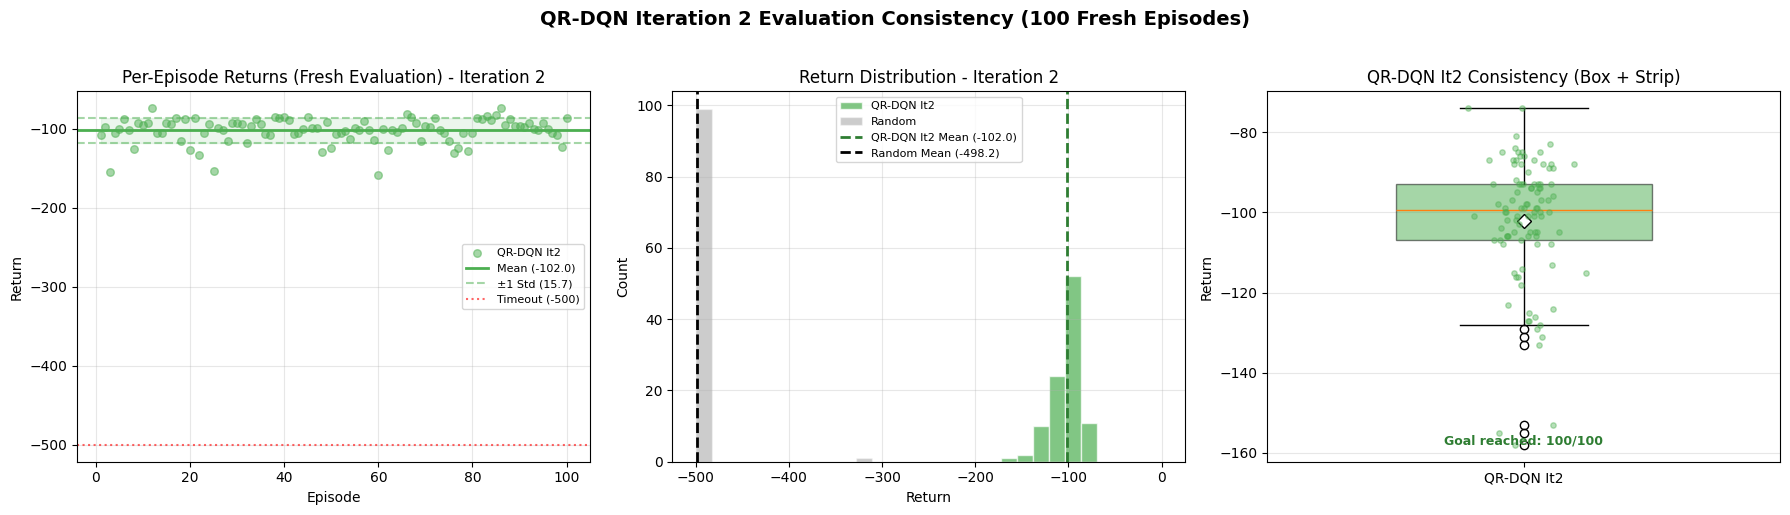

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Per-episode returns scatter
ax = axes[0]
episodes_it2 = np.arange(1, len(qrdqn_returns_it2) + 1)
ax.scatter(episodes_it2, qrdqn_returns_it2, alpha=0.5, s=30, color="#4CAF50", label="QR-DQN It2")
ax.axhline(y=qrdqn_mean_it2, color="#4CAF50", linestyle="-", linewidth=2, label=f"Mean ({qrdqn_mean_it2:.1f})")
ax.axhline(y=qrdqn_mean_it2 + qrdqn_std_it2, color="#4CAF50", linestyle="--", alpha=0.5, label=f"±1 Std ({qrdqn_std_it2:.1f})")
ax.axhline(y=qrdqn_mean_it2 - qrdqn_std_it2, color="#4CAF50", linestyle="--", alpha=0.5)
ax.fill_between(episodes_it2, qrdqn_mean_it2 - qrdqn_std_it2, qrdqn_mean_it2 + qrdqn_std_it2, color="#4CAF50", alpha=0.1)
ax.axhline(y=-500, color="red", linestyle=":", alpha=0.6, label="Timeout (-500)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Per-Episode Returns (Fresh Evaluation) - Iteration 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2) Histogram
ax = axes[1]
bins_it2 = np.linspace(min(min(qrdqn_returns_it2), min(rand_returns_it2)), 0, 30)
ax.hist(qrdqn_returns_it2, bins=bins_it2, alpha=0.7, color="#4CAF50", edgecolor="white", label="QR-DQN It2")
ax.hist(rand_returns_it2, bins=bins_it2, alpha=0.4, color="gray", edgecolor="white", label="Random")
ax.axvline(x=qrdqn_mean_it2, color="#2E7D32", linestyle="--", linewidth=2, label=f"QR-DQN It2 Mean ({qrdqn_mean_it2:.1f})")
ax.axvline(x=rand_mean_it2, color="black", linestyle="--", linewidth=2, label=f"Random Mean ({rand_mean_it2:.1f})")
ax.set_xlabel("Return")
ax.set_ylabel("Count")
ax.set_title("Return Distribution - Iteration 2")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) Box + strip plot — only QR-DQN It2
ax = axes[2]
data_it2 = [qrdqn_returns_it2]
labels_it2 = ["QR-DQN It2"]
colors_box_it2 = ["#4CAF50"]
bp_it2 = ax.boxplot(data_it2, labels=labels_it2, patch_artist=True, widths=0.5, showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=7))
for patch, color in zip(bp_it2["boxes"], colors_box_it2):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
jitter = np.random.normal(0, 0.04, size=len(qrdqn_returns_it2))
ax.scatter(np.full(len(qrdqn_returns_it2), 1) + jitter, qrdqn_returns_it2, alpha=0.4, s=15, color="#4CAF50", zorder=3)
ax.set_ylabel("Return")
ax.set_title("QR-DQN It2 Consistency (Box + Strip)")
ax.grid(True, alpha=0.3, axis="y")

qrdqn_success_it2 = sum(1 for r in qrdqn_returns_it2 if r > -500)
ax.annotate(f"Goal reached: {qrdqn_success_it2}/{len(qrdqn_returns_it2)}", xy=(1, min(qrdqn_returns_it2)),
            fontsize=9, ha="center", color="#2E7D32", fontweight="bold")

plt.suptitle("QR-DQN Iteration 2 Evaluation Consistency (100 Fresh Episodes)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("qrdqn_consistency_it2.png", dpi=150, bbox_inches='tight')
plt.show()

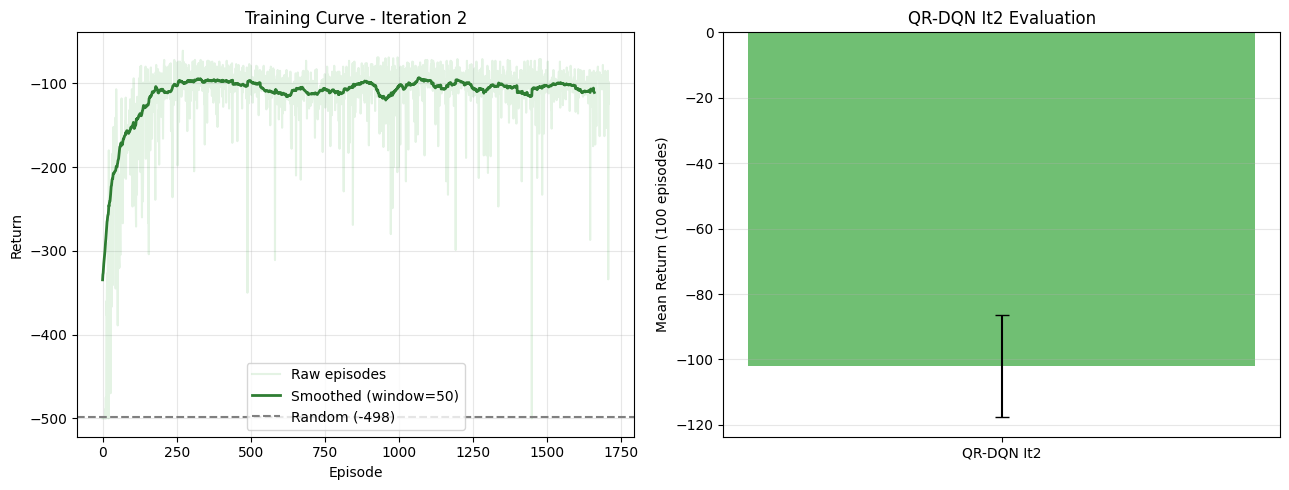

In [40]:
def smooth(rewards, window=50):
    return np.convolve(rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Training curve
ax = axes[0]
ax.plot(qrdqn_rewards_it2, alpha=0.15, color="#4CAF50", label="Raw episodes")
ax.plot(smooth(qrdqn_rewards_it2), label="Smoothed (window=50)", color="#2E7D32", linewidth=2)
ax.axhline(y=rand_mean_it2, color='gray', linestyle='--', label=f"Random ({rand_mean_it2:.0f})")
ax.set_xlabel("Episode")
ax.set_ylabel("Return")
ax.set_title("Training Curve - Iteration 2")
ax.legend()
ax.grid(True, alpha=0.3)

# Final evaluation
ax = axes[1]
ax.bar(["QR-DQN It2"], [qrdqn_mean_it2], yerr=[qrdqn_std_it2], capsize=5, color=["#4CAF50"], alpha=0.8)
ax.set_ylabel("Mean Return (100 episodes)")
ax.set_title("QR-DQN It2 Evaluation")
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("qrdqn_evaluation_it2.png", dpi=150, bbox_inches='tight')
plt.show()

## Eindevaluatie en reflectie

De resultaten van iteratie 1 en iteratie 2 tonen aan dat de gekozen QR-DQN aanpak geschikt is voor de Acrobot-taak. In iteratie 1 werd met een compacte architectuur (1584 parameters) stabiele performance bereikt rond −95. In iteratie 2 is het model verder verkleind naar 688 parameters, waarbij de performance licht daalt naar ongeveer −102. Deze daling is beperkt in verhouding tot de sterke reductie in modelgrootte (~57%), terwijl het model stabiel blijft leren en duidelijk beter presteert dan de baseline.

De vergelijking laat een duidelijke trade-off zien tussen performance en complexiteit. Iteratie 1 behaalt betere resultaten, maar iteratie 2 toont dat een veel kleiner model nog steeds functioneel is. Dit bevestigt dat de omgeving relatief eenvoudig is en geen grote netwerken vereist.

Een belangrijk inzicht uit de ruwe trainingscurves is dat beide iteraties episodische ruis vertonen, met name in de latere fase na convergentie. Dit wijst erop dat 8 quantielen niet voldoende zijn om de variantie in de value estimation volledig te dempen. Rond het convergentiepunt is de ruis beperkt en acceptabel, maar bij langer doortrainen neemt de instabiliteit toe. Dit is een teken van lichte overtraining: het model heeft al geconvergeerd, maar blijft parameters updaten waardoor het van het optimum af kan driften. Eerder stoppen (bijvoorbeeld via early stopping na convergentie) zou dit probleem voorkomen en zou resulteren in stabielere eindprestaties.

Kijkend naar de requirements worden de meeste eisen behaald. Het model leert stabiel tot aan convergentie (1), exploreert effectief (2), is geschikt voor de dynamica (3) en model-free (4). Daarnaast is het sample-efficiënt (5), schaalbaar (7) en werkt het correct zonder geheugen (9). De baseline wordt correct gebruikt en overtroffen (11, 12). Vooral requirement (10) en (13) zijn in iteratie 2 beter ingevuld, doordat de modelgrootte beter aansluit bij de complexiteit van het probleem.

Requirement (1), stabiel leren, is deels behaald: het model convergeert stabiel, maar de ruis na convergentie laat zien dat de distributional benadering met slechts 8 quantielen de variantie niet volledig absorbeert. Met meer quantielen of een early stopping mechanisme zou dit opgelost kunnen worden. Requirement (6), robuustheid voor hyperparameters, wordt niet volledig behaald. De noodzaak om de batch size aan te passen laat zien dat kleinere modellen gevoeliger zijn voor trainingsinstellingen.

De conclusie is dat het eindresultaat de meeste doelen behaalt. Hoewel hogere prestaties mogelijk zijn met grotere modellen, past iteratie 2 beter bij de gestelde requirements rondom modelcomplexiteit. De resterende ruis na convergentie is een bekend gevolg van een te laag aantal quantielen en kan in toekomstig werk worden aangepakt via meer quantielen, early stopping, of een alternatieve architectuur zoals een actor-critic die inherent minder variabel is in de updates.

## Expot of result image

In [33]:
env = gymnasium.make("Acrobot-v1", render_mode="rgb_array")
frames = []

state, _ = env.reset()
done = False
while not done:
    frame = env.render()
    frames.append(frame)
    action, _ = model_it2.predict(state, deterministic=True)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

# Capture final frame
frames.append(env.render())
env.close()

imageio.mimsave("qrdqn_acrobot_v2.gif", frames, fps=30, loop=0)
print(f"Saved GIF with {len(frames)} frames")

Saved GIF with 96 frames


<img src="./qrdqn_acrobot_v2.gif" alt="model choice flow" width="300"/>

### Sources

- [1] T. P. Lillicrap, J. J. Hunt, A. Pritzel, N. Heess, T. Erez, Y. Tassa, D. Silver, and D. Wierstra, "Continuous control with deep reinforcement learning," arXiv:1509.02971, 2019. https://arxiv.org/abs/1509.02971
- [2] F. Bongratz, V. Golkov, L. Mautner, L. Della Libera, F. Heetmeyer, F. Czaja, J. Rodemann, and D. Cremers, "How to Choose a Reinforcement-Learning Algorithm," arXiv:2407.20917, 2024. https://arxiv.org/abs/2407.20917
- [3] M. G. Bellemare, W. Dabney, and R. Munos, "A Distributional Perspective on Reinforcement Learning," arXiv:1707.06887, 2017. https://arxiv.org/abs/1707.06887
- [4] H. van Hasselt, A. Guez, and D. Silver, "Deep Reinforcement Learning with Double Q-learning," arXiv:1509.06461, 2015. https://arxiv.org/abs/1509.06461
- [5] P. Henderson, T. Doan, R. Islam, and D. Meger, "Bayesian Policy Gradients via Alpha Divergence Dropout Inference," arXiv:1712.02037, 2017. https://arxiv.org/abs/1712.02037
- [6] I. Osband, C. Blundell, A. Pritzel, and B. Van Roy, "Deep Exploration via Bootstrapped DQN," arXiv:1602.04621, 2016. https://arxiv.org/abs/1602.04621
- [7] DLR-RM, "RL Baselines3 Zoo (hyperparameter configurations and benchmarks)," GitHub repository. https://github.com/DLR-RM/rl-baselines3-zoo and https://stable-baselines3.readthedocs.io/en/master/guide/rl_zoo.html
- [8] P. Clavier, S. Allassonière, and E. Le Pennec, "Robust Reinforcement Learning with Distributional Risk-averse formulation," arXiv:2206.06841, 2022. https://arxiv.org/abs/2206.06841
- [9] Stable-Baselines3 Contributors, "QR-DQN Documentation," https://sb3-contrib.readthedocs.io/en/master/modules/qrdqn.html and A. Raffin, A. Hill, A. Gleave, A. Kanervisto, M. Ernestus, and N. Dormann, "Stable-Baselines3: Reliable Reinforcement Learning Implementations," Journal of Machine Learning Research, vol. 22, no. 268, pp. 1–8, 2021. http://jmlr.org/papers/v22/20-1364.html
- [10] W. Dabney, M. Rowland, M. G. Bellemare, and R. Munos, "Distributional Reinforcement Learning with Quantile Regression," arXiv:1710.10044, 2017. https://arxiv.org/abs/1710.10044